In [ ]:
# 이미지 파일 처리를 하기 위해서 필요한 package(module)이 있어요!
!conda install -c conda-forge tqdm        # progressbar를 표현할 수 있어요!
!conda install -c conda-forge ipywidgets  # progressbar를 표현하기 위해서 필요!
!conda install -c conda-forge opencv      # 이미지 처리(resize, 흑백처리)

In [2]:
# 이미지 파일을 읽어서 CSV 파일로 변환해보아요!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv   # opencv
from sklearn import utils  # sklearn이 제공하는 유틸리티 기능들
from tqdm.auto import tqdm # progressbar를 사용하기 위해
import os

In [ ]:
# 파일 경로
train_dir = 'C:/data/cat_dog/train/'

# 함수를 하나 생성
# 고양이 이미지는 0으로 멍멍이 이미지는 1로
# label을 생성하는 함수를 작성
def labeling(img):    # img : file명(ex. cat.0.jpg)
    class_name = img.split('.')[0]   # class_name => 'cat' or 'dog'
    if class_name == 'cat':
        return 0
    elif class_name == 'dog':
        return 1

# pixel data(x_data)와 label data(t_data)를 담을 리스트를 선언
x_data = []
t_data = []

file_list = os.listdir(train_dir)  # 특정폴더안에 있는 파일명들을 list로 담을 수 있어요!

for img in tqdm(file_list,
                total=len(file_list),
                position=0,
                leave=True):
    label_data = labeling(img)  # 현재 파일의 label(0 or 1)를 알아와요!
    # 이미지 파일의 전체 경로를 생성
    path = os.path.join(train_dir,img)  # 'C:/data/cat_dog/train/cat.0.jpg'
    # 이미지 파일의 ndarray를 가져오려면 (cv.imread())
    img_data = cv.resize(cv.imread(path, cv.IMREAD_GRAYSCALE), (80,80))

    # 1개의 파일의 대한 픽셀정보와 레이블정보가 준비되었으니
    x_data.append(img_data.ravel())
    t_data.append(label_data)

In [7]:
# DataFrame으로 변환시키면 될 거 같아요!
t_df = pd.DataFrame({
    'label': t_data
})

x_df = pd.DataFrame(x_data)  # 6400개의 pixel값이 각 column으로 생성.

In [8]:
df = pd.merge(t_df, x_df, left_index=True, right_index=True)

In [10]:
# DataFrame안에 있는 행들을 랜덤하게 섞어야 할 거 같아요!
shuffle_df = utils.shuffle(df)
# DataFrame을 CSV로 저장하면 될 거 같아요!
shuffle_df.to_csv('C:/data/cat_dog/' + "cat_dog_full_train.csv", 
                  index=False)

In [2]:
# 파일이 생성되었으니 CNN을 이용해서 고양이와 멍멍이 이진분류 모델을
# 만들어보아요!

# 필요한 module import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Model 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

In [3]:
# Raw Data Loading
df = pd.read_csv('C:/data/cat_dog/cat_dog_full_train.csv')
display(df.head(), df.shape)

,label,0,1,2,3,4,5,6,7,8,...,6390,6391,6392,6393,6394,6395,6396,6397,6398,6399
0,1,124,125,123,141,142,141,138,128,108,...,63,62,62,61,62,64,65,62,64,66
1,1,69,67,66,66,69,67,68,65,65,...,167,162,160,160,153,151,146,145,135,134
2,1,99,73,56,92,63,30,34,27,51,...,97,122,115,169,83,92,93,98,139,150
3,1,131,125,99,100,93,103,91,110,89,...,113,125,111,121,135,110,109,106,97,96
4,0,58,59,51,55,58,57,61,58,61,...,77,74,54,66,56,41,40,39,64,83


(25000, 6401)

In [4]:
# 데이터 분리
x_data = df.drop('label', axis=1, inplace=False).values
t_data = df['label'].values.reshape(-1,1)

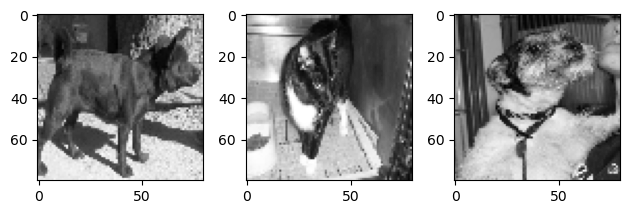

In [16]:
# 이미지 확인
fig = plt.figure()
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

ax1.imshow(x_data[152:153].reshape(80,80), cmap='gray')
ax2.imshow(x_data[162:163].reshape(80,80), cmap='gray')
ax3.imshow(x_data[182:183].reshape(80,80), cmap='gray')

plt.tight_layout()
plt.show()

In [5]:
# train과 test를 분리
x_data_train, x_data_test, t_data_train, t_data_test = \
train_test_split(x_data,
                t_data,
                test_size=0.3,
                stratify=t_data,
                random_state=42)
# 정규화 진행
scaler = MinMaxScaler()
scaler.fit(x_data_train)
x_data_train_norm = scaler.transform(x_data_train)
x_data_test_norm = scaler.transform(x_data_test)

In [6]:
# Model 구현
model = Sequential()

model.add(Conv2D(filters=32,
                kernel_size=(3,3),
                strides=(1,1),
                padding='SAME',
                activation='relu',
                input_shape=(80,80,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,
                kernel_size=(3,3),
                strides=(1,1),
                padding='SAME',
                activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=128,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(Conv2D(filters=256,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=256,
                kernel_size=(3,3),
                strides=(1,1),
                padding='VALID',
                activation='relu'))

# FC Layer ( Classifier )
model.add(Flatten())
model.add(Dropout(rate=0.5))

# Hidden Layer
model.add(Dense(units=128))
model.add(BatchNormalization())
model.add(Activation('relu'))

# output layer
model.add(Dense(units=1,
                activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 80, 80, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 40, 40, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 40, 40, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 20, 20, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 18, 18, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 256)       2

In [7]:
# Model 설정
model.compile(optimizer=RMSprop(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy'])

# callback 생성 - 일단 넘어가요!

In [ ]:
# Model 학습
history = model.fit(x_data_train_norm.reshape(-1,80,80,1),
                   t_data_train,
                   epochs=100,
                   verbose=1,
                   validation_split=0.3,
                   batch_size=100)

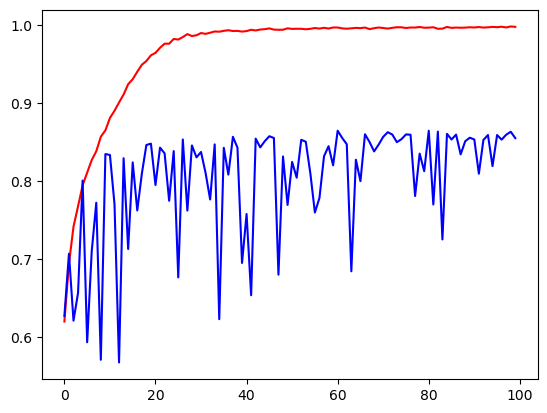

In [10]:
train_loss = history.history['accuracy']
val_loss = history.history['val_accuracy']

plt.plot(train_loss, color='r')
plt.plot(val_loss, color='b')

plt.show()


In [ ]:
# GPU를 이용해 보아요!
# 1. tensorflow버전이 GPU를 지원하는 버전이어야 해요!
#    기존버전(1.x)에서는 tensorflow-cpu, tensorflow-gpu가 따로 존재
#    각각 설치해서 사용했어야 해요! 하지만 이제는 tensorflow만 설치해도
#    GPU를 사용할 수 있어요!
# 2. CUDA, cuDNN 라이브러리를 설치
#    그럼 최신버전을 받아서 사용해야 하나요??
#    궁합이 잘 맞는 버전이 있어요.
#    Tensorflow 2.18.0, CUDA 11.8버전 사용, cuDNN 버전은 8.6 버전, python 버전 3.8

In [ ]:
# GPU를 사용하기 위해 Nvidia 사이트에서 CUDA와 cuDNN을 다운받아 설치하는 방법도 있지만
# Anaconda를 이용하여 보다 편하게 설정할 수 도 있습니다.

# Anaconda prompt를 관리자 권한으로 실행한 후 다음의 명령을 실행합니다.
# conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0
# pip install tensorflow==2.10.0

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))
print(tf.__version__)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
2.10.0
